<a href="https://colab.research.google.com/github/jerrinojacob/Data-Science-Portfolio/blob/main/Project_5/NATURAL_LANGUAGE_PROCESSING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Natural Language Processing



##PROBLEM DEFNITION

This Project aims to develop an interactive Natural Language Processing system that identifies similar individuals based on textual content analysis, comparing brief biographical overviews with comprehensive Wikipedia articles to evaluate content similarity and sentiment patterns.

This three-part project applies NLP techniques to analyze and compare the text data of famous individuals, progressing from a CSV data to dynamic Wikipedia content with an interactive user interface.

### Part 1



- The CSV file is available at https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv
- The file contains a list of famous people and a brief overview.
- The goal of part 1) is to ...
  1. Pick one person from the list ( the target person ) and output 10 other people who's overview are "closest" to the target person in a Natural Language Processing sense
  1. Also output the sentiment of the overview of the target person



#####Load Data

######Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from textblob import TextBlob

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

pd.options.display.max_columns = 100

import urllib.parse
import re

import nltk
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.neighbors import NearestNeighbors

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
import requests
import spacy
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

In [3]:
%%capture
# Download corpora
!pip3 install wikipedia-api
import wikipediaapi

In [4]:
%%capture
# Download corpora
!python -m textblob.download_corpora

#####Exploring the Data

In [5]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.5-NLP/Data/NLP.csv'
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: KD5WrvC+mQZzJZKaVoCuRAWIabxNk3SDJURMjK/1AEzpOELyguP/nAzkr0/EBZMSYVejZxwoCFw=
x-amz-request-id: B2EF7CP5XWPP1TFA
Date: Mon, 10 Nov 2025 22:22:18 GMT
Last-Modified: Mon, 23 Oct 2023 18:30:29 GMT
ETag: "f4f3b3bc07aa7b6dddb6e383fc52ae64-10"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 83886080
Server: AmazonS3



In [6]:
!curl -O {url}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.0M  100 80.0M    0     0  72.6M      0  0:00:01  0:00:01 --:--:-- 72.7M


In [7]:
!ls -lart

total 81936
drwxr-xr-x 4 root root     4096 Nov  7 14:30 .config
drwxr-xr-x 1 root root     4096 Nov  7 14:30 sample_data
drwxr-xr-x 1 root root     4096 Nov 10 22:19 ..
drwxr-xr-x 1 root root     4096 Nov 10 22:22 .
-rw-r--r-- 1 root root 83886080 Nov 10 22:22 NLP.csv


In [8]:
!file NLP.csv

NLP.csv: CSV text


In [9]:
!head -10 NLP.csv

URI,name,text
<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former australian rules footballer who played with the kangaroos and carlton in the australian football league aflfrom western australia morrell played his early senior football for west perth his 44game senior career for the falcons spanned 19982000 and he was the clubs leading goalkicker in 2000 at the age of 21 morrell was recruited to the australian football league by the kangaroos football club with its third round selection in the 2001 afl rookie draft as a forward he twice kicked five goals during his time with the kangaroos the first was in a losing cause against sydney in 2002 and the other the following season in a drawn game against brisbaneafter the 2003 season morrell was traded along with david teague to the carlton football club in exchange for corey mckernan he played 32 games for the blues before being delisted at the end of 2005 he continued to play victoria

#####Loading Dataset to Dataframes

In [10]:
df = pd.read_csv(url)
df

,URI,name,text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...
...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...


In [11]:
rows, cols = df.shape
f'There are {rows} rows and {cols} columns'

'There are 42786 rows and 3 columns'

In [12]:
f"There are {df.size:,} Elements in this data"

'There are 128,358 Elements in this data'

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


In [14]:
df.nunique()

,0
URI,42786
name,42785
text,42786


#####Checking for null values

In [15]:
df.isna().sum()

,0
URI,0
name,0
text,0


#####Data Quality check

In [16]:
df['name'].value_counts()>1

,count
name,
author),True
Kate Fodor,False
Kreg Battles,False
Robert Earnshaw,False
Clay Christiansen (organist),False
...,...
Chet Walker,False
Andreas Vanpoucke,False
Jill Robinson,False


In [17]:
df['name'].value_counts()[df['name'].value_counts()>1]

,count
name,
author),2


In [18]:
is_not_unique_mask = df['name'].duplicated(keep=False)
non_unique_rows_df = df[df['name'].duplicated(keep=False)]
non_unique_rows_df

,URI,name,text
787,<http://dbpedia.org/resource/James_Grieve_(tra...,author),james grieve born 1934 is an australian transl...
17249,<http://dbpedia.org/resource/Steve_Greenberg_(...,author),steve greenberg december 20 1960 is an america...


Checking for error in the csv file

In [19]:
!grep -n "james grieve" NLP.csv
!grep -n "steve greenberg" NLP.csv

789:<http://dbpedia.org/resource/James_Grieve_(translator/author)>,author),james grieve born 1934 is an australian translator of french literature and an author his translations have included scientific works books for children and two volumes of marcel prousts la recherche du temps perdu anu 1982 and penguin london 2002 grieves translated second part of prousts 7part remembrance of things past is the first completely new english translation since the 1920s there were six other translators working on the other parts for this project by penguin grieves penguin translation received positive review from alain de botton who remarked if one ends up with a favourite of the 7 volumes mine was james grieve who did volume 2 grieve is also the author of the language study text dictionary of contemporary french connectors routledge london 1996grieves translations have been illustrated by petr herel uncollected works press and phil day finlay press grieve is the author of three published novels in

Backup

In [20]:
df_nlp=df.copy()
df=df_nlp.copy()

Updating the names in error

In [21]:
df.loc[787, 'name'] = 'James Grieve'
df.loc[17251, 'name'] = 'Steve Greenberg'

In [22]:
df.loc[787],df.loc[17251]

(URI     <http://dbpedia.org/resource/James_Grieve_(tra...
 name                                         James Grieve
 text    james grieve born 1934 is an australian transl...
 Name: 787, dtype: object,
 URI           <http://dbpedia.org/resource/Bronwen_Maher>
 name                                      Steve Greenberg
 text    bronwen maher born 4 january 1957 is a former ...
 Name: 17251, dtype: object)

In [23]:
df['name'].value_counts()>1

,count
name,
Kenneth Thomas,False
Digby Morrell,False
Luke Walsh,False
Rachel Mackley,False
Martin Lee (tennis),False
...,...
Aaron LaCrate,False
Sam Henderson,False
G-Enka,False


In [24]:
df['name'].value_counts()[df['name'].value_counts()>1]

,count
name,


#####Data Processing

In [25]:
#Cleaning up the data
def preprocess_text(text):

  # Decode URL-encoded characters(e.g., %C3%A9 -> é)
  text = urllib.parse.unquote(text)

  # Lowercase the text
  text = text.lower()

  # Remove unwanted characters: parentheses, special characters, punctuation
    # Remove anything that's not a word or whitespace
  text = re.sub(r"[^\w\s]", "", text)
    # Remove leftover parentheses explicitly
  text = re.sub(r"|", "", text)
    # Tokenize and remove stopwords
  tokens = text.split()

  tokens = [word for word in tokens if word not in stop_words]

  return " ".join(tokens)

In [26]:
#Remove character '<' & '>' from the URI Column
df['addnl_URI'] = df['URI'].str.replace(r"[<>]","",regex=True)

#Preprocessing the name column
df['addtnl_name']  = df['name'].apply(preprocess_text)

#Preprocessing the text column
df['addtnl_text']  = df['text'].apply(preprocess_text)

df

,URI,name,text,addnl_URI,addtnl_name,addtnl_text
0,<http://dbpedia.org/resource/Digby_Morrell>,Digby Morrell,digby morrell born 10 october 1979 is a former...,http://dbpedia.org/resource/Digby_Morrell,digby morrell,digby morrell born 10 october 1979 former aust...
1,<http://dbpedia.org/resource/Alfred_J._Lewy>,Alfred J. Lewy,alfred j lewy aka sandy lewy graduated from un...,http://dbpedia.org/resource/Alfred_J._Lewy,alfred j lewy,alfred j lewy aka sandy lewy graduated univers...
2,<http://dbpedia.org/resource/Harpdog_Brown>,Harpdog Brown,harpdog brown is a singer and harmonica player...,http://dbpedia.org/resource/Harpdog_Brown,harpdog brown,harpdog brown singer harmonica player active c...
3,<http://dbpedia.org/resource/Franz_Rottensteiner>,Franz Rottensteiner,franz rottensteiner born in waidmannsfeld lowe...,http://dbpedia.org/resource/Franz_Rottensteiner,franz rottensteiner,franz rottensteiner born waidmannsfeld lower a...
4,<http://dbpedia.org/resource/G-Enka>,G-Enka,henry krvits born 30 december 1974 in tallinn ...,http://dbpedia.org/resource/G-Enka,genka,henry krvits born 30 december 1974 tallinn bet...
...,...,...,...,...,...,...
42781,<http://dbpedia.org/resource/Motoaki_Takenouchi>,Motoaki Takenouchi,motoaki takenouchi born july 8 1967 saitama pr...,http://dbpedia.org/resource/Motoaki_Takenouchi,motoaki takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,<http://dbpedia.org/resource/Alan_Judge_(footb...,"Alan Judge (footballer, born 1960)",alan graham judge born 14 may 1960 is a retire...,http://dbpedia.org/resource/Alan_Judge_(footba...,alan judge footballer born 1960,alan graham judge born 14 may 1960 retired pro...
42783,<http://dbpedia.org/resource/Eduardo_Lara>,Eduardo Lara,eduardo lara lozano born 4 september 1959 in c...,http://dbpedia.org/resource/Eduardo_Lara,eduardo lara,eduardo lara lozano born 4 september 1959 cali...
42784,<http://dbpedia.org/resource/Tatiana_Faberg%C3...,Tatiana Faberg%C3%A9,tatiana faberg is an author and faberg scholar...,http://dbpedia.org/resource/Tatiana_Faberg%C3%A9,tatiana fabergé,tatiana faberg author faberg scholar switzerla...


Backup #2

In [27]:
df_prepro = df.copy()

In [28]:
nlp_df=pd.DataFrame()

#####Dataframe with modified columns

In [29]:
#Creating a new df - NLP
nlp_df[['URI','name','text']] = df[['addnl_URI','addtnl_name','addtnl_text']].copy()
nlp_df

,URI,name,text
0,http://dbpedia.org/resource/Digby_Morrell,digby morrell,digby morrell born 10 october 1979 former aust...
1,http://dbpedia.org/resource/Alfred_J._Lewy,alfred j lewy,alfred j lewy aka sandy lewy graduated univers...
2,http://dbpedia.org/resource/Harpdog_Brown,harpdog brown,harpdog brown singer harmonica player active c...
3,http://dbpedia.org/resource/Franz_Rottensteiner,franz rottensteiner,franz rottensteiner born waidmannsfeld lower a...
4,http://dbpedia.org/resource/G-Enka,genka,henry krvits born 30 december 1974 tallinn bet...
...,...,...,...
42781,http://dbpedia.org/resource/Motoaki_Takenouchi,motoaki takenouchi,motoaki takenouchi born july 8 1967 saitama pr...
42782,http://dbpedia.org/resource/Alan_Judge_(footba...,alan judge footballer born 1960,alan graham judge born 14 may 1960 retired pro...
42783,http://dbpedia.org/resource/Eduardo_Lara,eduardo lara,eduardo lara lozano born 4 september 1959 cali...
42784,http://dbpedia.org/resource/Tatiana_Faberg%C3%A9,tatiana fabergé,tatiana faberg author faberg scholar switzerla...


In [30]:
nlp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42786 entries, 0 to 42785
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   URI     42786 non-null  object
 1   name    42786 non-null  object
 2   text    42786 non-null  object
dtypes: object(3)
memory usage: 1002.9+ KB


#####Choosing Target and their Details:
#####David Wood (idx:736)
#####Kenneth James Gibson (idx:119)

In [31]:
nlp_df.iloc[736]
# nlp_df.iloc[119]

,736
URI,http://dbpedia.org/resource/David_Wood_(Christ...
name,david wood christian apologist
text,david wood american evangelical missionary phi...


In [32]:
target_idx = 736
target_name = nlp_df.iloc[target_idx]['name']
target_text = nlp_df.iloc[target_idx]['text']
# target_idx = 119
# target_name = nlp_df.iloc[target_idx]['name']
# target_text = nlp_df.iloc[target_idx]['text']

In [33]:
target_name

'david wood christian apologist'

In [34]:
target_text

'david wood american evangelical missionary philosophy lecturer currently head acts 17 apologetics ministry degrees philosophy biology pursuing phd philosophy religion academic institution state new york also claimed member society christian philosopherswood participated numerous public debates muslims atheists usually public hall front university audience wood invited several abn shows interreligious discussions atheism islam among things regularly appears aramaic broadcasting network wood stated former atheist produced youtube videos presenting views religionwood opposed park51 islamic center arguing meant honor victims families instead symbol islamic victory named cordoba house memory islamic conquest spain umayyad caliphate later formed caliphate crdoba wood disagreed pastor terry jones 2010 quranburning controversy comparing uthman quran burningwood arrested outside dearborn michigan preaching arab festival charged misdemeanor disturbing peace later acquitted may 2013 city dearbor

#####Sentiment Analysis

In [35]:
target_senti=TextBlob(target_text).sentiment
target_senti

Sentiment(polarity=0.018636363636363635, subjectivity=0.2218006993006993)

#####TF-IDF

In [36]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_vec = tfidf_vectorizer.fit_transform(nlp_df['text'])
target_vec = tfidf_vectorizer.transform([target_text])

#####Nearest Neighbor Model

In [37]:
nn = NearestNeighbors(n_neighbors=11)
nn.fit(tfidf_vec)

NearestNeighbors(n_neighbors=11)

#####Finding the Nearest Neighbor of the Target

In [38]:
distances, indices = nn.kneighbors(X=target_vec)

In [39]:
distances

array([[0.        , 1.20604506, 1.25569017, 1.26133065, 1.27169608,
        1.27497426, 1.27551548, 1.27910373, 1.2801579 , 1.2865972 ,
        1.28793582]])

#####Retrieving indices of the 10 nearest neighbors without the Target

In [40]:
nn_indices = indices[0][1:]

#####Extracting the nearest 10 neighbors text

In [41]:
nn_text = nlp_df['text'].iloc[nn_indices].tolist()
nn_text

['kerry lee wood born june 16 1977 american former major league baseball pitcher career played chicago cubs cleveland indians new york yankees wood first came prominence twentyyear old rookie recorded twenty strikeouts onehit shutout houston astros argued may greatest singlegame pitching performance major league baseball history game also made wood coholder mlb record strikeouts single game 20 earned wood nickname kid k later named 1998 national league rookie year wood would go record 200 strikeouts four first five seasons high 266 2003 holds several mlb strikeout recordsthough struggled injuries throughout career wood twice named allstar wood transitioned relief pitching 2007 due continued struggles injuries ultimately reviving career closer career wood placed disabled list 14 times 13 major league seasons included missing entire 1999 season due tommy john surgery slow start 2012 season wood retired may 18 2012',
 'jasper wood born april 29 1974 moncton new brunswick canadian concert 

#####Output Sentiment

######Calculating the Sentiment Analysis for the nearest 10 neighbors

In [42]:
nn_senti = nn_text
nn_senti = [TextBlob(text).sentiment for  text in nn_text]
nn_senti

[Sentiment(polarity=0.011410220214568046, subjectivity=0.36958686241294936),
 Sentiment(polarity=0.044480519480519475, subjectivity=0.25183982683982686),
 Sentiment(polarity=0.07864646464646464, subjectivity=0.27630303030303033),
 Sentiment(polarity=0.10650294150294148, subjectivity=0.35171106671106667),
 Sentiment(polarity=0.10386363636363637, subjectivity=0.3863510101010101),
 Sentiment(polarity=0.05900178253119429, subjectivity=0.35196078431372557),
 Sentiment(polarity=0.07552230378317336, subjectivity=0.2567099567099568),
 Sentiment(polarity=0.077, subjectivity=0.1418888888888889),
 Sentiment(polarity=0.061231060606060615, subjectivity=0.29184659090909093),
 Sentiment(polarity=0.15517316017316019, subjectivity=0.41380952380952396)]

In [43]:
nn_senti_pol = [TextBlob(text).sentiment.polarity for  text in nn_text]
nn_senti_pol

[0.011410220214568046,
 0.044480519480519475,
 0.07864646464646464,
 0.10650294150294148,
 0.10386363636363637,
 0.05900178253119429,
 0.07552230378317336,
 0.077,
 0.061231060606060615,
 0.15517316017316019]

######Checking for Polarity as Positive, Negative, Neutral

In [44]:
def polarity_check(polarity):
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

In [45]:
nn_polarity_check = [polarity_check(polarity) for polarity in nn_senti_pol]
nn_polarity_check

['positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'positive']

######Moving the Nearest Neighbors and the their Sentiment check into a df

In [46]:
nn_nlp_df = pd.DataFrame(
  {
  'index':nn_indices,
  'url':nlp_df['URI'].iloc[nn_indices].tolist(),
  'name':nlp_df['name'].iloc[nn_indices].tolist(),
  'text':nlp_df['text'].iloc[nn_indices].tolist(),
  'sentiment_polarity':nn_senti_pol,
  'sentiment_class':nn_polarity_check,
  }
)

In [47]:
nn_nlp_df

,index,url,name,text,sentiment_polarity,sentiment_class
0,40239,http://dbpedia.org/resource/Kerry_Wood,kerry wood,kerry lee wood born june 16 1977 american form...,0.011410,positive
1,35419,http://dbpedia.org/resource/Jasper_Wood,jasper wood,jasper wood born april 29 1974 moncton new bru...,0.044481,positive
2,15799,http://dbpedia.org/resource/Michael_Wood_(acad...,michael wood academic,michael wood born lincoln england director gau...,0.078646,positive
3,42144,http://dbpedia.org/resource/Gerry_Wood,gerry wood,gerard vincent gerry wood born 5 april 1950 au...,0.106503,positive
4,24637,http://dbpedia.org/resource/Diane_Wood,diane wood,diane pamela wood born july 4 1950 chief judge...,0.103864,positive
5,3894,http://dbpedia.org/resource/Jeff_Wood_(prisoner),jeff wood prisoner,jeffery lee wood born august 19 1973 scheduled...,0.059002,positive
6,21821,http://dbpedia.org/resource/Graeme_Wood_(busin...,graeme wood businessman,graeme wood born 1947 rockhampton queensland a...,0.075522,positive
7,9228,http://dbpedia.org/resource/Melanie_Wood,melanie wood,melanie matchett wood born 1981 american mathe...,0.077000,positive
8,27352,http://dbpedia.org/resource/Howard_Wood,howard wood,james howard wood born may 20 1959 retired ame...,0.061231,positive
9,22702,http://dbpedia.org/resource/Chris_Wood_(folk_m...,chris wood folk musician,chris wood english folk musician composer play...,0.155173,positive


In [48]:
nn_nlp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               10 non-null     int64  
 1   url                 10 non-null     object 
 2   name                10 non-null     object 
 3   text                10 non-null     object 
 4   sentiment_polarity  10 non-null     float64
 5   sentiment_class     10 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 612.0+ bytes


######Creating a Target df

In [49]:
target_nlp_df = pd.DataFrame(
  {
  'index':[target_idx],
  'url':[nlp_df.iloc[target_idx]['URI']],
  'name':[target_name],
  'text':[target_text],
  'sentiment_polarity':[TextBlob(target_text).sentiment.polarity],
  'sentiment_class':[polarity_check(TextBlob(target_text).sentiment.polarity)],
  }
)
target_nlp_df

,index,url,name,text,sentiment_polarity,sentiment_class
0,736,http://dbpedia.org/resource/David_Wood_(Christ...,david wood christian apologist,david wood american evangelical missionary phi...,0.018636,positive


Combining the Target and Nearest neighbor into 1 df

In [50]:
target_nn_df=pd.concat([target_nlp_df, nn_nlp_df],ignore_index=True)
target_nn_df

,index,url,name,text,sentiment_polarity,sentiment_class
0,736,http://dbpedia.org/resource/David_Wood_(Christ...,david wood christian apologist,david wood american evangelical missionary phi...,0.018636,positive
1,40239,http://dbpedia.org/resource/Kerry_Wood,kerry wood,kerry lee wood born june 16 1977 american form...,0.011410,positive
2,35419,http://dbpedia.org/resource/Jasper_Wood,jasper wood,jasper wood born april 29 1974 moncton new bru...,0.044481,positive
3,15799,http://dbpedia.org/resource/Michael_Wood_(acad...,michael wood academic,michael wood born lincoln england director gau...,0.078646,positive
4,42144,http://dbpedia.org/resource/Gerry_Wood,gerry wood,gerard vincent gerry wood born 5 april 1950 au...,0.106503,positive
5,24637,http://dbpedia.org/resource/Diane_Wood,diane wood,diane pamela wood born july 4 1950 chief judge...,0.103864,positive
6,3894,http://dbpedia.org/resource/Jeff_Wood_(prisoner),jeff wood prisoner,jeffery lee wood born august 19 1973 scheduled...,0.059002,positive
7,21821,http://dbpedia.org/resource/Graeme_Wood_(busin...,graeme wood businessman,graeme wood born 1947 rockhampton queensland a...,0.075522,positive
8,9228,http://dbpedia.org/resource/Melanie_Wood,melanie wood,melanie matchett wood born 1981 american mathe...,0.077000,positive
9,27352,http://dbpedia.org/resource/Howard_Wood,howard wood,james howard wood born may 20 1959 retired ame...,0.061231,positive


In [51]:
target_nn_df

,index,url,name,text,sentiment_polarity,sentiment_class
0,736,http://dbpedia.org/resource/David_Wood_(Christ...,david wood christian apologist,david wood american evangelical missionary phi...,0.018636,positive
1,40239,http://dbpedia.org/resource/Kerry_Wood,kerry wood,kerry lee wood born june 16 1977 american form...,0.011410,positive
2,35419,http://dbpedia.org/resource/Jasper_Wood,jasper wood,jasper wood born april 29 1974 moncton new bru...,0.044481,positive
3,15799,http://dbpedia.org/resource/Michael_Wood_(acad...,michael wood academic,michael wood born lincoln england director gau...,0.078646,positive
4,42144,http://dbpedia.org/resource/Gerry_Wood,gerry wood,gerard vincent gerry wood born 5 april 1950 au...,0.106503,positive
5,24637,http://dbpedia.org/resource/Diane_Wood,diane wood,diane pamela wood born july 4 1950 chief judge...,0.103864,positive
6,3894,http://dbpedia.org/resource/Jeff_Wood_(prisoner),jeff wood prisoner,jeffery lee wood born august 19 1973 scheduled...,0.059002,positive
7,21821,http://dbpedia.org/resource/Graeme_Wood_(busin...,graeme wood businessman,graeme wood born 1947 rockhampton queensland a...,0.075522,positive
8,9228,http://dbpedia.org/resource/Melanie_Wood,melanie wood,melanie matchett wood born 1981 american mathe...,0.077000,positive
9,27352,http://dbpedia.org/resource/Howard_Wood,howard wood,james howard wood born may 20 1959 retired ame...,0.061231,positive


In [52]:
target_nn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               11 non-null     int64  
 1   url                 11 non-null     object 
 2   name                11 non-null     object 
 3   text                11 non-null     object 
 4   sentiment_polarity  11 non-null     float64
 5   sentiment_class     11 non-null     object 
dtypes: float64(1), int64(1), object(4)
memory usage: 660.0+ bytes


In [53]:
target_nn_df['name'] = target_nn_df['name'].str.title()
target_nn_df['name']

,name
0,David Wood Christian Apologist
1,Kerry Wood
2,Jasper Wood
3,Michael Wood Academic
4,Gerry Wood
5,Diane Wood
6,Jeff Wood Prisoner
7,Graeme Wood Businessman
8,Melanie Wood
9,Howard Wood


In [54]:
target_name = target_name.title()
target_name

'David Wood Christian Apologist'

In [55]:
target_index=target_nn_df[target_nn_df['name'] == target_name].index[0]
target_index

np.int64(0)

#####Scatterplot: Sentiment Scores

<Figure size 1500x500 with 0 Axes>

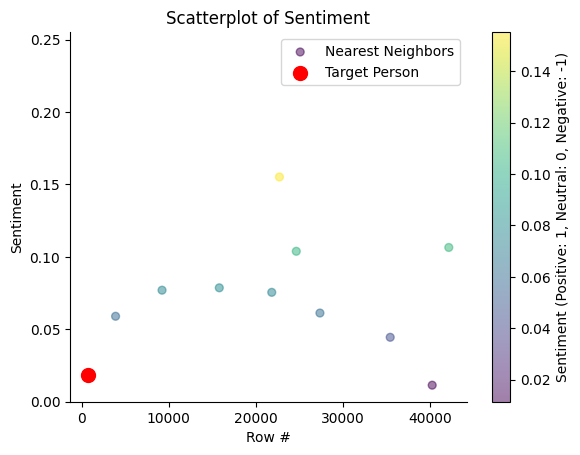

In [56]:
plt.figure(figsize=(15,5))

# Plot nearest neighbors without colorbar
scatter = target_nn_df[target_nn_df.index != target_index].plot(
    kind='scatter'
    , x='index'
    , y='sentiment_polarity'
    , s=32
    , alpha=0.5
    , c='sentiment_polarity'
    , cmap='viridis'
    , label='Nearest Neighbors'
    , colorbar=False
)

# Plot target person
plt.scatter(
    target_nn_df.loc[target_index, 'index']
    , target_nn_df.loc[target_index, 'sentiment_polarity']
    , color='red'
    , s=100
    , label='Target Person'
    )

plt.xlabel('Row #')
plt.ylabel('Sentiment')
plt.title('Scatterplot of Sentiment')

# Create a single colorbar for the 'viridis' colormap
plt.colorbar(
    scatter.collections[0]
    , label='Sentiment (Positive: 1, Neutral: 0, Negative: -1)'
)

plt.ylim(0.0, target_nn_df['sentiment_polarity'].max() + 0.10)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend();

#####Ranking the Nearest Neighbors to the Target

In [57]:
target_nn_df.sort_values(by=['sentiment_polarity'], ascending=False)

,index,url,name,text,sentiment_polarity,sentiment_class
10,22702,http://dbpedia.org/resource/Chris_Wood_(folk_m...,Chris Wood Folk Musician,chris wood english folk musician composer play...,0.155173,positive
4,42144,http://dbpedia.org/resource/Gerry_Wood,Gerry Wood,gerard vincent gerry wood born 5 april 1950 au...,0.106503,positive
5,24637,http://dbpedia.org/resource/Diane_Wood,Diane Wood,diane pamela wood born july 4 1950 chief judge...,0.103864,positive
3,15799,http://dbpedia.org/resource/Michael_Wood_(acad...,Michael Wood Academic,michael wood born lincoln england director gau...,0.078646,positive
8,9228,http://dbpedia.org/resource/Melanie_Wood,Melanie Wood,melanie matchett wood born 1981 american mathe...,0.077000,positive
7,21821,http://dbpedia.org/resource/Graeme_Wood_(busin...,Graeme Wood Businessman,graeme wood born 1947 rockhampton queensland a...,0.075522,positive
9,27352,http://dbpedia.org/resource/Howard_Wood,Howard Wood,james howard wood born may 20 1959 retired ame...,0.061231,positive
6,3894,http://dbpedia.org/resource/Jeff_Wood_(prisoner),Jeff Wood Prisoner,jeffery lee wood born august 19 1973 scheduled...,0.059002,positive
2,35419,http://dbpedia.org/resource/Jasper_Wood,Jasper Wood,jasper wood born april 29 1974 moncton new bru...,0.044481,positive
0,736,http://dbpedia.org/resource/David_Wood_(Christ...,David Wood Christian Apologist,david wood american evangelical missionary phi...,0.018636,positive


### Part 2



- For the same target person that you chose in Part 1), use the Wikipedia API to access the whole content of the target person's Wikipedia page.
- The goal of Part 2) is to ...
  1. Print out the text of the Wikipedia article for the target person
  1. Determine the sentiment of the text of the Wikipedia page for the target person
  1. Collect the text of the Wikipedia pages from the 10 nearest neighbors from Part 1)
  1. Determine the nearness ranking of these 10 people to your target person based on their entire Wikipedia page
  1. Compare, i.e. plot,  the nearest ranking from Step 1) with the Wikipedia page nearness ranking.  A difference of the rank is one means of comparison.



In [58]:
target_nn_df['name'] = target_nn_df['name'].apply(urllib.parse.unquote)
target_nn_df['url'] = target_nn_df['url'].apply(urllib.parse.unquote)
target_nn_df[['name','url']]

,name,url
0,David Wood Christian Apologist,http://dbpedia.org/resource/David_Wood_(Christ...
1,Kerry Wood,http://dbpedia.org/resource/Kerry_Wood
2,Jasper Wood,http://dbpedia.org/resource/Jasper_Wood
3,Michael Wood Academic,http://dbpedia.org/resource/Michael_Wood_(acad...
4,Gerry Wood,http://dbpedia.org/resource/Gerry_Wood
5,Diane Wood,http://dbpedia.org/resource/Diane_Wood
6,Jeff Wood Prisoner,http://dbpedia.org/resource/Jeff_Wood_(prisoner)
7,Graeme Wood Businessman,http://dbpedia.org/resource/Graeme_Wood_(busin...
8,Melanie Wood,http://dbpedia.org/resource/Melanie_Wood
9,Howard Wood,http://dbpedia.org/resource/Howard_Wood


In [59]:
target_nn_df['url'].tolist()

['http://dbpedia.org/resource/David_Wood_(Christian_apologist)',
 'http://dbpedia.org/resource/Kerry_Wood',
 'http://dbpedia.org/resource/Jasper_Wood',
 'http://dbpedia.org/resource/Michael_Wood_(academic)',
 'http://dbpedia.org/resource/Gerry_Wood',
 'http://dbpedia.org/resource/Diane_Wood',
 'http://dbpedia.org/resource/Jeff_Wood_(prisoner)',
 'http://dbpedia.org/resource/Graeme_Wood_(businessman)',
 'http://dbpedia.org/resource/Melanie_Wood',
 'http://dbpedia.org/resource/Howard_Wood',
 'http://dbpedia.org/resource/Chris_Wood_(folk_musician)']

#####TF_IDF & Nearest Neighbor Model

###### Initialize Wikipedia API

In [60]:
wikip = wikipediaapi.Wikipedia(user_agent='wiki-abc')

In [61]:
def process_wiki_text(wiki_page_title, person_name):
    try:
        # Fetch Wikipedia page content
        page_ex = wikip.page(wiki_page_title)
        wiki_text = page_ex.text

        # Check if Wikipedia text is empty
        if not wiki_text.strip():
            print(f"Skipping '{person_name}' due to empty Wikipedia content.")
            return None

        # Clean the Wikipedia text by removing newlines
        wiki_text_clean = wiki_text.replace("\n", " ")

        return wiki_text_clean

    except Exception as e:
        print(f"Error fetching Wikipedia content for '{person_name}': {e}")
        return None

In [62]:
target_nn_df.columns

Index(['index', 'url', 'name', 'text', 'sentiment_polarity',
       'sentiment_class'],
      dtype='object')

In [63]:
wiki_list = []
for index, row in target_nn_df.iterrows():
    person_name = row['name']

    wiki_page_title = row['url'].split('/')[-1]

    wiki_content_clean = process_wiki_text(wiki_page_title, person_name)

    if wiki_content_clean is not None:
        wiki_list.append({
            'index': row['index'],
            'name': row['name'],
            'text': row['text'],
            'sentiment_polarity': row['sentiment_polarity'],
            'sentiment_class': row['sentiment_class'],
            'wiki_page': row['url'],
            'wiki_content': wiki_content_clean
        })

In [64]:
wiki_list

[{'index': 736,
  'name': 'David Wood Christian Apologist',
  'text': 'david wood american evangelical missionary philosophy lecturer currently head acts 17 apologetics ministry degrees philosophy biology pursuing phd philosophy religion academic institution state new york also claimed member society christian philosopherswood participated numerous public debates muslims atheists usually public hall front university audience wood invited several abn shows interreligious discussions atheism islam among things regularly appears aramaic broadcasting network wood stated former atheist produced youtube videos presenting views religionwood opposed park51 islamic center arguing meant honor victims families instead symbol islamic victory named cordoba house memory islamic conquest spain umayyad caliphate later formed caliphate crdoba wood disagreed pastor terry jones 2010 quranburning controversy comparing uthman quran burningwood arrested outside dearborn michigan preaching arab festival char

In [65]:
wiki_df=pd.DataFrame(wiki_list)

In [66]:
wiki_df

,index,name,text,sentiment_polarity,sentiment_class,wiki_page,wiki_content
0,736,David Wood Christian Apologist,david wood american evangelical missionary phi...,0.018636,positive,http://dbpedia.org/resource/David_Wood_(Christ...,"David Wood (born April 7, 1976) is an American..."
1,40239,Kerry Wood,kerry lee wood born june 16 1977 american form...,0.011410,positive,http://dbpedia.org/resource/Kerry_Wood,"Kerry Lee Wood (born June 16, 1977) is an Amer..."
2,35419,Jasper Wood,jasper wood born april 29 1974 moncton new bru...,0.044481,positive,http://dbpedia.org/resource/Jasper_Wood,"Jasper Wood (born April 29, 1974) is a Canadia..."
3,15799,Michael Wood Academic,michael wood born lincoln england director gau...,0.078646,positive,http://dbpedia.org/resource/Michael_Wood_(acad...,"Michael Wood (born Lincoln, 19 August 1936) is..."
4,42144,Gerry Wood,gerard vincent gerry wood born 5 april 1950 au...,0.106503,positive,http://dbpedia.org/resource/Gerry_Wood,Gerard Vincent Wood (born 5 April 1950) is an ...
5,24637,Diane Wood,diane pamela wood born july 4 1950 chief judge...,0.103864,positive,http://dbpedia.org/resource/Diane_Wood,"Diane Pamela Wood (born July 4, 1950) is an Am..."
6,3894,Jeff Wood Prisoner,jeffery lee wood born august 19 1973 scheduled...,0.059002,positive,http://dbpedia.org/resource/Jeff_Wood_(prisoner),"Jeffery Lee ""Jeff"" Wood (born August 19, 1973)..."
7,21821,Graeme Wood Businessman,graeme wood born 1947 rockhampton queensland a...,0.075522,positive,http://dbpedia.org/resource/Graeme_Wood_(busin...,Graeme Thomas Wood (born 1947) is an Australi...
8,9228,Melanie Wood,melanie matchett wood born 1981 american mathe...,0.077000,positive,http://dbpedia.org/resource/Melanie_Wood,Melanie Matchett Wood (born 1981) is an Americ...
9,27352,Howard Wood,james howard wood born may 20 1959 retired ame...,0.061231,positive,http://dbpedia.org/resource/Howard_Wood,Howard Wood may refer to: Politicians Howard ...


#####Sentiment Analysis

In [67]:
#initializing Sentiment Analyzer
sa = SentimentIntensityAnalyzer()

In [68]:
def polarity_check(polarity):
    if polarity >= 0.05:
        return 'positive'
    elif polarity <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [69]:
#TD-IDF
tfidf2_vectorizer = TfidfVectorizer(stop_words='english')
tfidf2_matrix = tfidf_vectorizer.fit_transform(wiki_df['wiki_content'])
tfidf2_data = tfidf2_matrix.toarray().tolist()
wiki_df['tfidf_matrix_wiki'] = tfidf2_data

In [70]:
def get_sentiment_polarity(text):
    return sa.polarity_scores(text)['compound']

In [71]:
wiki_df['sentiment_polarity'] = wiki_df['wiki_content'].apply(get_sentiment_polarity)
wiki_df['sentiment_class'] = wiki_df['sentiment_polarity'].apply(polarity_check)
wiki_df

,index,name,text,sentiment_polarity,sentiment_class,wiki_page,wiki_content,tfidf_matrix_wiki
0,736,David Wood Christian Apologist,david wood american evangelical missionary phi...,-0.9826,negative,http://dbpedia.org/resource/David_Wood_(Christ...,"David Wood (born April 7, 1976) is an American...","[0.011350888738056788, 0.0, 0.0, 0.0, 0.0, 0.0..."
1,40239,Kerry Wood,kerry lee wood born june 16 1977 american form...,0.9982,positive,http://dbpedia.org/resource/Kerry_Wood,"Kerry Lee Wood (born June 16, 1977) is an Amer...","[0.013027976566771767, 0.0, 0.0, 0.0, 0.0, 0.0..."
2,35419,Jasper Wood,jasper wood born april 29 1974 moncton new bru...,0.9892,positive,http://dbpedia.org/resource/Jasper_Wood,"Jasper Wood (born April 29, 1974) is a Canadia...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,15799,Michael Wood Academic,michael wood born lincoln england director gau...,-0.8860,negative,http://dbpedia.org/resource/Michael_Wood_(acad...,"Michael Wood (born Lincoln, 19 August 1936) is...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,42144,Gerry Wood,gerard vincent gerry wood born 5 april 1950 au...,-0.3620,negative,http://dbpedia.org/resource/Gerry_Wood,Gerard Vincent Wood (born 5 April 1950) is an ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.01993653313435919,..."
5,24637,Diane Wood,diane pamela wood born july 4 1950 chief judge...,0.9883,positive,http://dbpedia.org/resource/Diane_Wood,"Diane Pamela Wood (born July 4, 1950) is an Am...","[0.0, 0.0, 0.0, 0.0, 0.006502336439818077, 0.0..."
6,3894,Jeff Wood Prisoner,jeffery lee wood born august 19 1973 scheduled...,-0.9992,negative,http://dbpedia.org/resource/Jeff_Wood_(prisoner),"Jeffery Lee ""Jeff"" Wood (born August 19, 1973)...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,21821,Graeme Wood Businessman,graeme wood born 1947 rockhampton queensland a...,0.9858,positive,http://dbpedia.org/resource/Graeme_Wood_(busin...,Graeme Thomas Wood (born 1947) is an Australi...,"[0.03277585629028087, 0.0, 0.0, 0.0, 0.0, 0.0,..."
8,9228,Melanie Wood,melanie matchett wood born 1981 american mathe...,0.9836,positive,http://dbpedia.org/resource/Melanie_Wood,Melanie Matchett Wood (born 1981) is an Americ...,"[0.0, 0.028694808307607036, 0.0286948083076070..."
9,27352,Howard Wood,james howard wood born may 20 1959 retired ame...,0.0000,neutral,http://dbpedia.org/resource/Howard_Wood,Howard Wood may refer to: Politicians Howard ...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [72]:
#Target Person
target_person_index = 0
target_vector = tfidf2_matrix[target_person_index]

In [73]:
# Calculate cosine similarity
similarities = cosine_similarity(target_vector, tfidf2_matrix)

In [74]:
# Find nearest neighbors
num_neighbors = 10
wiki_neighbor_indices = similarities.argsort()[0][-num_neighbors - 1:-1][::-1]

In [75]:
wiki_neighbors = wiki_df.iloc[wiki_neighbor_indices][['index', 'name', 'sentiment_polarity', 'sentiment_class', 'text', 'wiki_page', 'tfidf_matrix_wiki']]

wiki_neighbors = wiki_neighbors.sort_values(by='sentiment_polarity', ascending=False)

wiki_neighbors

,index,name,sentiment_polarity,sentiment_class,text,wiki_page,tfidf_matrix_wiki
10,22702,Chris Wood Folk Musician,0.9987,positive,chris wood english folk musician composer play...,http://dbpedia.org/resource/Chris_Wood_(folk_m...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,40239,Kerry Wood,0.9982,positive,kerry lee wood born june 16 1977 american form...,http://dbpedia.org/resource/Kerry_Wood,"[0.013027976566771767, 0.0, 0.0, 0.0, 0.0, 0.0..."
2,35419,Jasper Wood,0.9892,positive,jasper wood born april 29 1974 moncton new bru...,http://dbpedia.org/resource/Jasper_Wood,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,24637,Diane Wood,0.9883,positive,diane pamela wood born july 4 1950 chief judge...,http://dbpedia.org/resource/Diane_Wood,"[0.0, 0.0, 0.0, 0.0, 0.006502336439818077, 0.0..."
7,21821,Graeme Wood Businessman,0.9858,positive,graeme wood born 1947 rockhampton queensland a...,http://dbpedia.org/resource/Graeme_Wood_(busin...,"[0.03277585629028087, 0.0, 0.0, 0.0, 0.0, 0.0,..."
8,9228,Melanie Wood,0.9836,positive,melanie matchett wood born 1981 american mathe...,http://dbpedia.org/resource/Melanie_Wood,"[0.0, 0.028694808307607036, 0.0286948083076070..."
9,27352,Howard Wood,0.0000,neutral,james howard wood born may 20 1959 retired ame...,http://dbpedia.org/resource/Howard_Wood,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,42144,Gerry Wood,-0.3620,negative,gerard vincent gerry wood born 5 april 1950 au...,http://dbpedia.org/resource/Gerry_Wood,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.01993653313435919,..."
3,15799,Michael Wood Academic,-0.8860,negative,michael wood born lincoln england director gau...,http://dbpedia.org/resource/Michael_Wood_(acad...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,3894,Jeff Wood Prisoner,-0.9992,negative,jeffery lee wood born august 19 1973 scheduled...,http://dbpedia.org/resource/Jeff_Wood_(prisoner),"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [76]:
print(f"Nearest Neighbors to #{wiki_df.iloc[target_person_index]['index']} {wiki_df.iloc[target_person_index]['name']} ({wiki_df.iloc[target_person_index]['sentiment_polarity']}):")

Nearest Neighbors to #736 David Wood Christian Apologist (-0.9826):


In [77]:
# Ensure the final output matches the desired structure
wiki_neighbors[['index', 'name', 'sentiment_polarity', 'sentiment_class']]

,index,name,sentiment_polarity,sentiment_class
10,22702,Chris Wood Folk Musician,0.9987,positive
1,40239,Kerry Wood,0.9982,positive
2,35419,Jasper Wood,0.9892,positive
5,24637,Diane Wood,0.9883,positive
7,21821,Graeme Wood Businessman,0.9858,positive
8,9228,Melanie Wood,0.9836,positive
9,27352,Howard Wood,0.0000,neutral
4,42144,Gerry Wood,-0.3620,negative
3,15799,Michael Wood Academic,-0.8860,negative
6,3894,Jeff Wood Prisoner,-0.9992,negative


#####Scatter plot

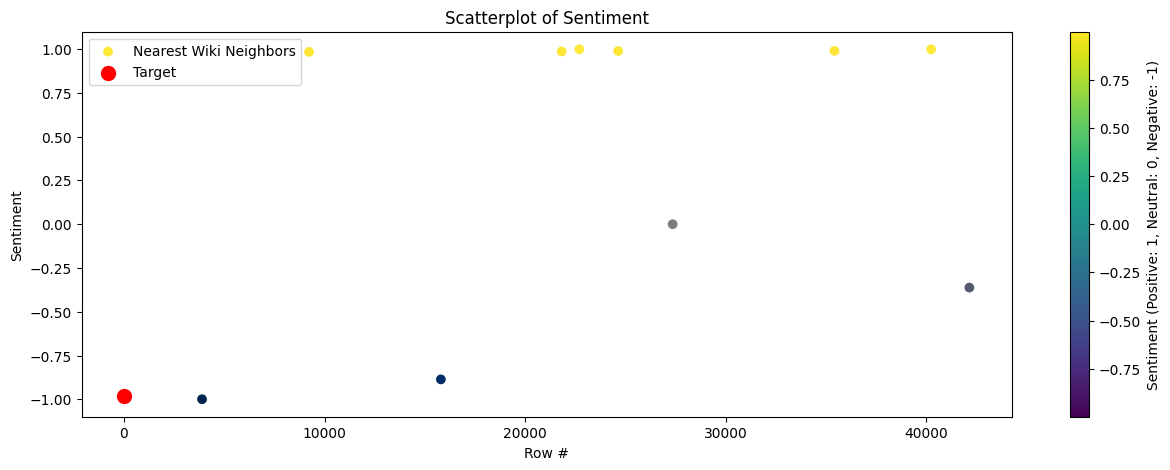

In [78]:
plt.figure(figsize=(15, 5))
wiki_plot = plt.scatter(
    wiki_neighbors['index']
    , wiki_neighbors['sentiment_polarity']
    , c=wiki_neighbors['sentiment_polarity']
    , cmap='cividis'
    , label= 'Nearest Wiki Neighbors'
)

target_person = wiki_df.iloc[[target_person_index]]

plt.scatter(
    target_person.index
    , target_person['sentiment_polarity']
    , color='red'
    , label='Target'
    , s=100
)

plt.xlabel('Row #')
plt.ylabel('Sentiment')
plt.title('Scatterplot of Sentiment')

#ScalarMappable for the colorbar
norm = plt.Normalize(wiki_neighbors['sentiment_polarity'].min(), wiki_neighbors['sentiment_polarity'].max())
cmap = plt.get_cmap('viridis')

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # This line is important to prevent an error
plt.colorbar(sm, ax=wiki_plot.axes, label='Sentiment (Positive: 1, Neutral: 0, Negative: -1)')
plt.legend();

### Part 3


Make an interactive notebook where a user can choose or enter a name and the notebook displays the 10 closest individuals.

In addition to presenting the project slides, at the end of the presentation each student will demonstrate their code using a famous person suggested by the other students that exists in the DBpedia set.


In [79]:
def get_nearest_neighbors(name_input, df=nlp_df, top_n=10):

    # Preprocess the input name
    processed_name = preprocess_text(name_input)

    # Find matching names in the dataset
    matches = df[df['name'].str.lower() == processed_name.lower()]

    if len(matches) == 0:
        print(f"No exact match found for '{name_input}'")
        print("\nDid you mean one of these?")
        # Find similar names
        similar = df[df['name'].str.contains(processed_name.split()[0], case=False, na=False)]['name'].unique()[:5]
        for i, name in enumerate(similar, 1):
            print(f"{i}. {name.title()}")
        return None

    # Get the first match (in case of duplicates)
    target_idx = matches.index[0]
    target_name = df.iloc[target_idx]['name']
    target_text = df.iloc[target_idx]['text']

    print(f"Found: {target_name.title()}")
    print(f"Index: {target_idx}")
    print("-" * 50)

    # Calculate TF-IDF for target
    tfidf_vectorizer = TfidfVectorizer()
    tfidf_vec = tfidf_vectorizer.fit_transform(df['text'])
    target_vec = tfidf_vectorizer.transform([target_text])

    # Find nearest neighbors
    nn = NearestNeighbors(n_neighbors=top_n + 1)
    nn.fit(tfidf_vec)
    distances, indices = nn.kneighbors(X=target_vec)

    # Get indices excluding the target itself
    nn_indices = indices[0][1:]

    # Extract nearest neighbors data
    nn_text = df['text'].iloc[nn_indices].tolist()
    nn_senti_pol = [TextBlob(text).sentiment.polarity for text in nn_text]
    nn_polarity_check = [polarity_check(polarity) for polarity in nn_senti_pol]

    # Create nearest neighbors dataframe
    nn_df = pd.DataFrame({
        'index': nn_indices,
        'url': df['URI'].iloc[nn_indices].tolist(),
        'name': df['name'].iloc[nn_indices].tolist(),
        'text': df['text'].iloc[nn_indices].tolist(),
        'sentiment_polarity': nn_senti_pol,
        'sentiment_class': nn_polarity_check,
    })

    # Create target dataframe
    target_df = pd.DataFrame({
        'index': [target_idx],
        'url': [df.iloc[target_idx]['URI']],
        'name': [target_name],
        'text': [target_text],
        'sentiment_polarity': [TextBlob(target_text).sentiment.polarity],
        'sentiment_class': [polarity_check(TextBlob(target_text).sentiment.polarity)],
    })

    # Combine target and nearest neighbors
    result_df = pd.concat([target_df, nn_df], ignore_index=True)
    result_df['name'] = result_df['name'].str.title()

    return result_df, target_idx

In [80]:
def ten_neighbors():
  in_name = input("Please enter your name: ")
  result_df, target_idx = get_nearest_neighbors(in_name)
  print(f"The list of 10 neighbors of {in_name}\n\n{result_df['name']}")

**!!Enter a Name!!!**

In [81]:
#Uncomment the function below and Run
# ten_neighbors()